In [ ]:
# Cell 1: fetch real Bank Rate data from the BoE database
import requests
import pandas as pd
import io

url = "https://www.bankofengland.co.uk/boeapps/database/_iadb-fromshowcolumns.asp"
params = {
    "csv.x": "yes",
    "Datefrom": "01/Jan/2015",
    "Dateto": "01/Jan/2025",
    "SeriesCodes": "IUDBEDR",   # Bank Rate series code
    "CSVF": "TN",
    "UsingCodes": "Y",
    "VPD": "Y",
    "VFD": "N",
}
headers = {"User-Agent": "Mozilla/5.0"}
resp = requests.get(url, params=params, headers=headers)

df_real = pd.read_csv(io.StringIO(resp.text))
df_real.columns = ["date", "rate"]
df_real["date"] = pd.to_datetime(df_real["date"], format="%d %b %Y", errors="coerce")
df_real = df_real.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

print(df_real.head())
print(df_real.tail())
print(f"Rows: {len(df_real)}")

        date  rate
0 2015-01-02   0.5
1 2015-01-05   0.5
2 2015-01-06   0.5
3 2015-01-07   0.5
4 2015-01-08   0.5
           date  rate
2521 2024-12-23  4.75
2522 2024-12-24  4.75
2523 2024-12-27  4.75
2524 2024-12-30  4.75
2525 2024-12-31  4.75
Rows: 2526


In [ ]:
df_real

,date,rate
0,2015-01-02,0.50
1,2015-01-05,0.50
2,2015-01-06,0.50
3,2015-01-07,0.50
4,2015-01-08,0.50
...,...,...
2521,2024-12-23,4.75
2522,2024-12-24,4.75
2523,2024-12-27,4.75
2524,2024-12-30,4.75


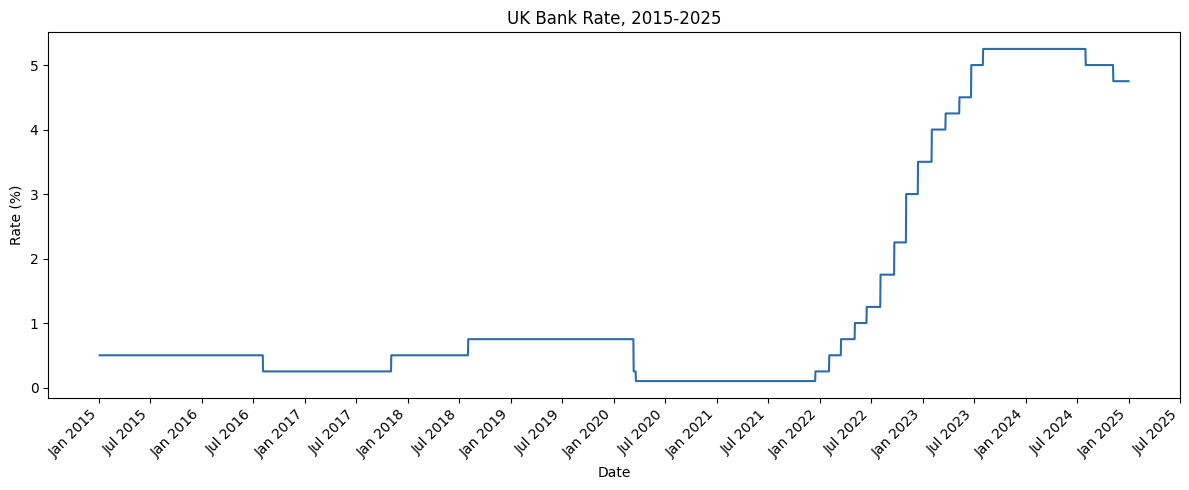

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_real["date"], df_real["rate"], color="#2b6cb0")
ax.set_title("UK Bank Rate, 2015-2025")
ax.set_xlabel("Date")
ax.set_ylabel("Rate (%)")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6)) # Show major ticks every 6 months
plt.xticks(rotation=45, ha='right') # Rotate labels for better visibility
plt.tight_layout()
plt.show()

ARIMA RMSE forecasting into the hiking cycle: 1.0919


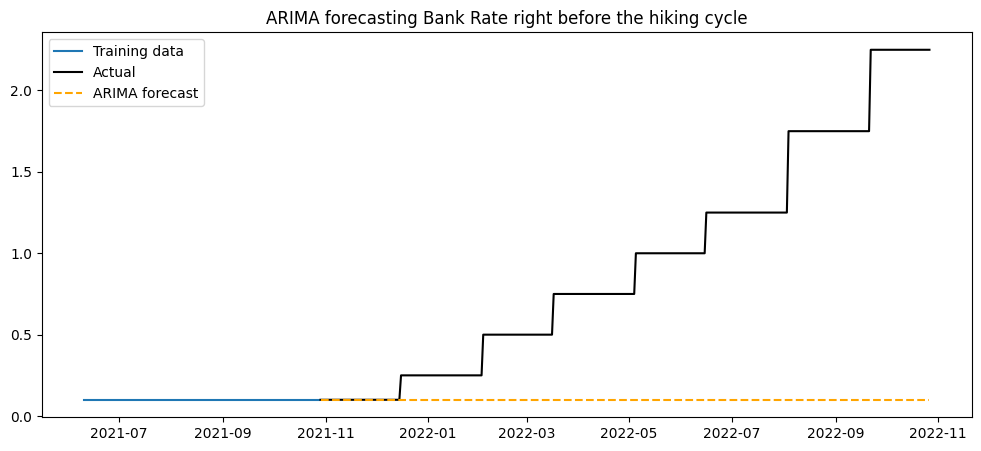

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

rate = df_real["rate"].values
dates = df_real["date"].values

# "Today" = just before the hiking cycle started (Nov 2021)
cutoff_date = pd.Timestamp("2021-11-01")
train_end = df_real[df_real["date"] < cutoff_date].index[-1]

train = rate[:train_end]
actual_future = rate[train_end:train_end + 250]  # roughly a year ahead

fit = ARIMA(train, order=(2, 1, 2)).fit()
forecast = fit.forecast(steps=250)

rmse = np.sqrt(np.mean((forecast - actual_future) ** 2))
print(f"ARIMA RMSE forecasting into the hiking cycle: {rmse:.4f}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dates[train_end-100:train_end], train[-100:], label="Training data")
ax.plot(dates[train_end:train_end+250], actual_future, label="Actual", color="black")
ax.plot(dates[train_end:train_end+250], forecast, label="ARIMA forecast", color="orange", linestyle="--")
ax.legend()
ax.set_title("ARIMA forecasting Bank Rate right before the hiking cycle")
plt.show()

In [ ]:
from prophet import Prophet

prophet_df = df_real.rename(columns={"date": "ds", "rate": "y"})
train_p = prophet_df.iloc[:train_end]
actual_p = prophet_df.iloc[train_end:train_end + 250]

model = Prophet(
    changepoint_prior_scale=0.05,
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=False
)
model.fit(train_p)

future = model.make_future_dataframe(periods=250, freq="D")
forecast = model.predict(future)

forecast_vals = forecast["yhat"].iloc[train_end:train_end+250].values
actual_vals = actual_p["y"].values
rmse_prophet = np.sqrt(np.mean((forecast_vals - actual_vals) ** 2))
print(f"Prophet RMSE: {rmse_prophet:.4f}")

# Check Prophet's detected changepoints
changepoints = model.changepoints
cp_deltas = model.params['delta'].mean(axis=0)
biggest_cp_idx = np.argmax(np.abs(cp_deltas))
print(f"Prophet's biggest detected changepoint: {changepoints.iloc[biggest_cp_idx].date()}")
print(f"(The BoE's first hike was on 2021-12-16)")

Prophet RMSE: 1.0978
Prophet's biggest detected changepoint: 2020-06-18
(The BoE's first hike was on 2021-12-16)


 Prophet's changepoint detector measures how much the slope changes at a single point — and one sharp, sudden vertical jump (the COVID cut) produces a bigger single-point slope change than a staircase of small gradual steps, even though the staircase's total cumulative change was much larger and arguably more economically important. Prophet essentially got distracted by the sharpest single event rather than the most consequential structural shift.

In [ ]:
!pip install -q ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.5 MB/s eta 0:00:00


In [ ]:
import ruptures as rpt

rate_values = df_real["rate"].values

# Ask for the single most significant level-shift
algo = rpt.Binseg(model="l2").fit(rate_values)
single_bp = algo.predict(n_bkps=1)
detected_date = df_real["date"].iloc[single_bp[0]]
print(f"Ruptures' single biggest detected break: {detected_date.date()}")

# Also ask for the TOP 3, since we know there are at least 2 real events
# (the COVID cut AND the hiking cycle start)
three_bp = rpt.Binseg(model="l2").fit(rate_values).predict(n_bkps=3)
print(f"Top 3 breaks: {[df_real['date'].iloc[i].date() for i in three_bp[:-1]]}")

Ruptures' single biggest detected break: 2022-11-02
Top 3 breaks: [datetime.date(2022, 6, 13), datetime.date(2022, 11, 2), datetime.date(2023, 5, 12)]


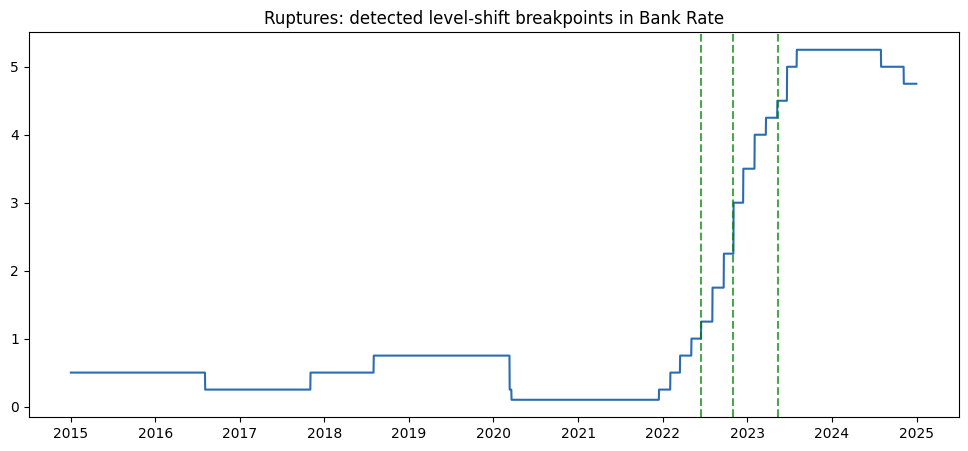

In [ ]:
# Visualize
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_real["date"], rate_values, color="#2b6cb0")
for bp in three_bp[:-1]:
    ax.axvline(df_real["date"].iloc[bp], color="green", linestyle="--", alpha=0.7)
ax.set_title("Ruptures: detected level-shift breakpoints in Bank Rate")
plt.show()

In [ ]:
import ruptures as rpt

algo_pelt = rpt.Pelt(model="l2").fit(rate_values)
bp_pelt = algo_pelt.predict(pen=1)   # try a few penalty values below

print(f"Detected breakpoints (dates): {[df_real['date'].iloc[i].date() for i in bp_pelt[:-1]]}")

# Try a couple of penalty values to see the sensitivity, same tradeoff we saw with Prophet
for pen in [0.5, 1, 2, 5]:
    bps = rpt.Pelt(model="l2").fit(rate_values).predict(pen=pen)
    dates = [df_real['date'].iloc[i].date() for i in bps[:-1]]
    print(f"pen={pen}: {len(dates)} breaks -> {dates}")

Detected breakpoints (dates): [datetime.date(2016, 8, 2), datetime.date(2017, 11, 6), datetime.date(2018, 8, 1), datetime.date(2020, 3, 13), datetime.date(2022, 1, 31), datetime.date(2022, 3, 21), datetime.date(2022, 6, 13), datetime.date(2022, 8, 8), datetime.date(2022, 9, 21), datetime.date(2022, 11, 2), datetime.date(2022, 12, 14), datetime.date(2023, 2, 6), datetime.date(2023, 5, 12), datetime.date(2023, 6, 26), datetime.date(2023, 8, 7), datetime.date(2024, 8, 1), datetime.date(2024, 11, 8)]
pen=0.5: 20 breaks -> [datetime.date(2016, 8, 2), datetime.date(2017, 11, 6), datetime.date(2018, 8, 1), datetime.date(2020, 3, 13), datetime.date(2021, 12, 15), datetime.date(2022, 2, 7), datetime.date(2022, 3, 21), datetime.date(2022, 5, 5), datetime.date(2022, 6, 20), datetime.date(2022, 8, 8), datetime.date(2022, 9, 21), datetime.date(2022, 11, 2), datetime.date(2022, 12, 14), datetime.date(2023, 2, 6), datetime.date(2023, 3, 27), datetime.date(2023, 5, 12), datetime.date(2023, 6, 26), dat

In [ ]:
!pip install -q hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 5.0 MB/s eta 0:00:00


Low-rate regime: mean=-0.535
High-rate regime: mean=1.686
Entered current regime around: 2022-08-04


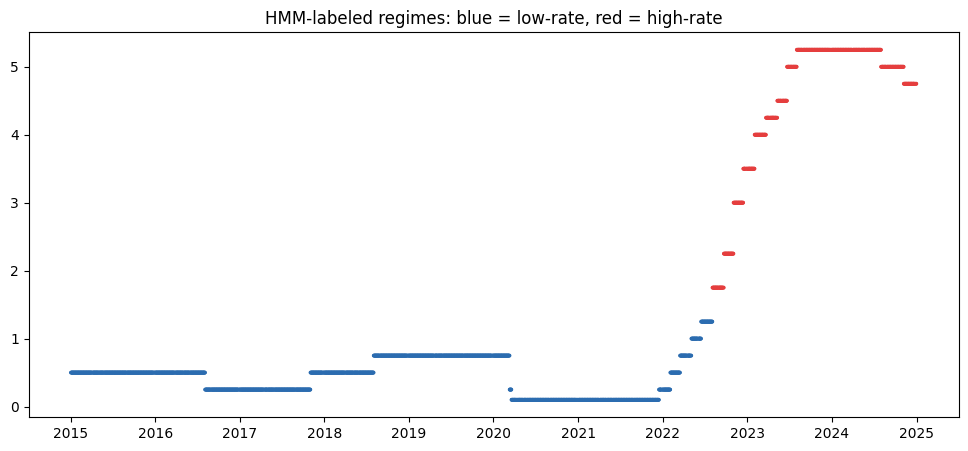

In [ ]:
from hmmlearn import hmm

# Rate LEVEL itself is meaningful here (unlike FX), so we standardize the raw level
rate_scaled = ((rate_values - rate_values.mean()) / rate_values.std()).reshape(-1, 1)

model = hmm.GaussianHMM(n_components=2, covariance_type="diag", n_iter=200, random_state=42)
model.fit(rate_scaled)
hidden_states = model.predict(rate_scaled)

means = model.means_.flatten()
low_state = np.argmin(means)
high_state = np.argmax(means)

print(f"Low-rate regime: mean={means[low_state]:.3f}")
print(f"High-rate regime: mean={means[high_state]:.3f}")

# When did we enter the current (most recent) regime?
current_state = hidden_states[-1]
switch_idx = np.where(np.diff((hidden_states == current_state).astype(int)) == 1)[0]
if len(switch_idx) > 0:
    print(f"Entered current regime around: {df_real['date'].iloc[switch_idx[-1]+1].date()}")

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2b6cb0" if s == low_state else "#e53e3e" for s in hidden_states]
ax.scatter(df_real["date"], rate_values, c=colors, s=3)
ax.set_title("HMM-labeled regimes: blue = low-rate, red = high-rate")
plt.show()

What's missing, concretely:


1.   It doesn't run on its own. We manually picked cutoff dates and reran  cells. A real tool needs to look at today's data and tell you today's regime, automatically, on a schedule — not require you to know in advance where to look.

2.   It doesn't run on its own. We manually picked cutoff dates and reran cells. A real tool needs to look at today's data and tell you today's regime, automatically, on a schedule — not require you to know in advance where to look.

3. It doesn't speak human. "State 1, mean=4.2, std=1.35" means nothing to almost anyone, including probably future-you in six months. Someone needs to translate "here's the regime, here's how long it's lasted, here's how unusual that is" into a sentence a person can actually read and trust.
It doesn't remember itself. Right now, if we ran this again next week, we'd have no memory of what we said last week — no way to check "did we call the last regime shift correctly," no track record, nothing accumulating in value over time.

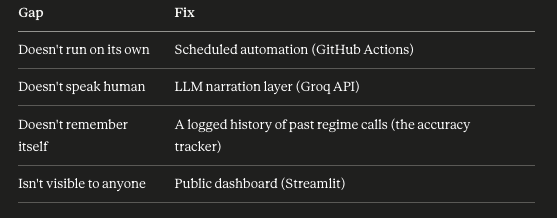